# Public Impact Forecast and Story Recommendation

This notebook is an IS 455 machine learning pipeline for the INTEX project. It is built to support the public donor-facing impact dashboard and the admin publishing workflow that decides what impact story to highlight next month.


In [1]:
import ast
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import JSON, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 27
def find_repo_root():
    start = Path.cwd().resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "lighthouse_csv_v7").exists():
            return candidate
    return start

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "lighthouse_csv_v7"

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

def parse_payload(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        return ast.literal_eval(str(value))
    except (ValueError, SyntaxError):
        return {}

def metric_frame(actual, predicted, target_names):
    rows = []
    for idx, target_name in enumerate(target_names):
        rows.append(
            {
                "target": target_name,
                "RMSE": np.sqrt(mean_squared_error(actual[:, idx], predicted[:, idx])),
                "MAE": mean_absolute_error(actual[:, idx], predicted[:, idx]),
                "R2": r2_score(actual[:, idx], predicted[:, idx]),
            }
        )
    return pd.DataFrame(rows)

snapshots = pd.read_csv(DATA_DIR / "public_impact_snapshots.csv", parse_dates=["snapshot_date", "published_at"])
safehouse = pd.read_csv(DATA_DIR / "safehouse_monthly_metrics.csv", parse_dates=["month_start", "month_end"])
allocations = pd.read_csv(DATA_DIR / "donation_allocations.csv", parse_dates=["allocation_date"])
donations = pd.read_csv(DATA_DIR / "donations.csv", parse_dates=["donation_date"])

print("Loaded tables:", {
    "public_impact_snapshots": len(snapshots),
    "safehouse_monthly_metrics": len(safehouse),
    "donation_allocations": len(allocations),
    "donations": len(donations),
})


Loaded tables: {'public_impact_snapshots': 50, 'safehouse_monthly_metrics': 450, 'donation_allocations': 521, 'donations': 420}


# 1. Problem Framing

**Business question.** What impact metrics should the organization highlight publicly next month, and what impact trends should donors expect?

**Who uses this analysis.**
- Communications and donor-relations staff use it to decide what should appear on the public dashboard.
- Admins use it in the reports page and monthly publishing workflow.
- Leadership uses it to communicate transparent outcomes to donors without exposing sensitive resident-level detail.

**Two connected modeling goals.**
- **Forecasting component:** predict next month's public impact metrics so staff can prepare donor-facing updates before publishing.
- **Recommendation component:** recommend which metric or story should be highlighted as the lead public narrative next month.

**Why both matter.** The forecast helps the organization anticipate what the dashboard may show next month. The recommendation component decides which trend is most worth elevating to donors, balancing operational improvement, trend strength, and donor relevance.

**Primary forecast targets.**
- active residents served
- average health score
- average education progress
- total donation impact

**Primary recommendation output.**
- `headline_priority_score` used to rank which metric should be featured in the public monthly story

**Success criteria.**
- Reasonable out-of-sample RMSE and MAE on holdout months
- Forecasts that can be explained in donor-facing language
- A recommendation framework that is transparent enough for staff to justify publicly

**Executive Takeaway.** This pipeline is designed for donor transparency and public communications, not just internal analytics. It should help the team forecast next month's dashboard and pick the strongest impact story to tell.


# 2. Data Acquisition, Preparation & Exploration

**Relevant tables and join logic.**
- `public_impact_snapshots.csv` supplies the already-published donor-facing monthly summaries.
- `safehouse_monthly_metrics.csv` provides operational context like active residents, education progress, health score, and incident counts.
- `donation_allocations.csv` adds information about how funds were directed by month and program area.
- `donations.csv` adds donation volume and donation-impact context by month.

**Join grain.** Everything is aggregated to monthly grain before joining, because the publishing decision is monthly and the public impact snapshots are monthly.

**Important preparation detail.** The `metric_payload_json` field is parsed and expanded into separate numeric columns so the forecasting target is explicit and reproducible.


In [2]:
snapshots = snapshots.sort_values("snapshot_date").reset_index(drop=True)
payload_df = pd.json_normalize(snapshots["metric_payload_json"].apply(parse_payload))
payload_df.columns = [f"payload_{column}" for column in payload_df.columns]
snapshots_expanded = pd.concat([snapshots.drop(columns=["metric_payload_json"]), payload_df], axis=1)
snapshots_expanded["month"] = snapshots_expanded["snapshot_date"].dt.to_period("M").dt.to_timestamp()

donations["donation_value"] = pd.to_numeric(donations["amount"], errors="coerce").fillna(
    pd.to_numeric(donations["estimated_value"], errors="coerce")
)
donations["month"] = donations["donation_date"].dt.to_period("M").dt.to_timestamp()
donations_monthly = donations.groupby("month").agg(
    total_donations_value=("donation_value", "sum"),
    donation_count=("donation_id", "size"),
    recurring_share=("is_recurring", "mean"),
    campaign_count=("campaign_name", "nunique"),
).reset_index()

allocations["month"] = allocations["allocation_date"].dt.to_period("M").dt.to_timestamp()
allocations_monthly = allocations.groupby("month").agg(
    total_allocations=("amount_allocated", "sum"),
    allocation_count=("allocation_id", "size"),
    safehouses_funded=("safehouse_id", "nunique"),
    program_areas_funded=("program_area", "nunique"),
).reset_index()
allocation_mix = (
    allocations.pivot_table(
        index="month",
        columns="program_area",
        values="amount_allocated",
        aggfunc="sum",
        fill_value=0,
    )
    .add_prefix("allocation_")
    .reset_index()
)
allocations_monthly = allocations_monthly.merge(allocation_mix, on="month", how="left")

safehouse["month"] = safehouse["month_start"].dt.to_period("M").dt.to_timestamp()
safehouse_monthly = safehouse.groupby("month").agg(
    active_residents=("active_residents", "sum"),
    avg_health_score=("avg_health_score", "mean"),
    avg_education_progress=("avg_education_progress", "mean"),
    process_recording_count=("process_recording_count", "sum"),
    home_visitation_count=("home_visitation_count", "sum"),
    incident_count=("incident_count", "sum"),
).reset_index()

monthly = (
    snapshots_expanded.merge(safehouse_monthly, on="month", how="left")
    .merge(allocations_monthly, on="month", how="left")
    .merge(donations_monthly, on="month", how="left")
    .sort_values("month")
    .reset_index(drop=True)
)

monthly["published_flag"] = monthly["is_published"].astype(int)
monthly["month_num"] = monthly["month"].dt.month
monthly["quarter"] = monthly["month"].dt.quarter
monthly["year"] = monthly["month"].dt.year

monthly["headline_length"] = monthly["headline"].fillna("").str.len()
monthly["summary_length"] = monthly["summary_text"].fillna("").str.len()

forecast_targets = {
    "forecast_active_residents_served": monthly["payload_total_residents"].fillna(monthly["active_residents"]),
    "forecast_avg_health_score": monthly["payload_avg_health_score"].fillna(monthly["avg_health_score"]),
    "forecast_avg_education_progress": monthly["payload_avg_education_progress"].fillna(monthly["avg_education_progress"]),
    "forecast_total_donation_impact": monthly["payload_donations_total_for_month"].fillna(monthly["total_donations_value"]),
}
for target_name, values in forecast_targets.items():
    monthly[target_name] = pd.to_numeric(values, errors="coerce")

base_lag_columns = [
    "active_residents",
    "avg_health_score",
    "avg_education_progress",
    "incident_count",
    "total_allocations",
    "total_donations_value",
    "donation_count",
    "payload_total_residents",
    "payload_avg_health_score",
    "payload_avg_education_progress",
    "payload_donations_total_for_month",
]

for column in base_lag_columns:
    if column not in monthly.columns:
        continue
    monthly[f"{column}_lag1"] = monthly[column].shift(1)
    monthly[f"{column}_lag2"] = monthly[column].shift(2)
    monthly[f"{column}_rolling3"] = monthly[column].rolling(3, min_periods=1).mean().shift(1)
    monthly[f"{column}_delta1"] = monthly[column].diff(1)
    monthly[f"{column}_yoy_delta"] = monthly[column] - monthly[column].shift(12)

monthly["donation_to_allocation_ratio"] = monthly["total_donations_value"] / monthly["total_allocations"].replace(0, np.nan)
monthly["incident_pressure"] = monthly["incident_count"] / monthly["active_residents"].replace(0, np.nan)
monthly["health_to_education_ratio"] = monthly["avg_health_score"] / monthly["avg_education_progress"].replace(0, np.nan)

next_month = monthly["month"].shift(-1)
monthly["target_month"] = next_month
target_columns = list(forecast_targets.keys())
for column in target_columns:
    monthly[f"{column}_next"] = monthly[column].shift(-1)

modeling_df = monthly.dropna(subset=[f"{column}_next" for column in target_columns]).copy()

display(monthly.head())
print("Monthly modeling rows:", len(modeling_df))


,snapshot_id,snapshot_date,headline,summary_text,is_published,published_at,payload_month,payload_avg_health_score,payload_avg_education_progress,payload_total_residents,...,payload_donations_total_for_month_delta1,payload_donations_total_for_month_yoy_delta,donation_to_allocation_ratio,incident_pressure,health_to_education_ratio,target_month,forecast_active_residents_served_next,forecast_avg_health_score_next,forecast_avg_education_progress_next,forecast_total_donation_impact_next
0,1,2023-01-01,Lighthouse Sanctuary Impact Update - January 2023,Anonymized aggregate report: 60 residents acti...,True,2023-01-01,2023-01,3.03,33.90,60,...,NaN,NaN,1.059979,0.000000,0.089381,2023-02-01,60.0,3.13,51.05,2065.15
1,2,2023-02-01,Lighthouse Sanctuary Impact Update - February ...,Anonymized aggregate report: 60 residents acti...,True,2023-02-01,2023-02,3.13,51.05,60,...,685.23,NaN,1.229227,0.000000,0.061312,2023-03-01,60.0,3.16,60.57,9577.83
2,3,2023-03-01,Lighthouse Sanctuary Impact Update - March 2023,Anonymized aggregate report: 60 residents acti...,True,2023-03-01,2023-03,3.16,60.57,60,...,7512.68,NaN,1.034323,0.000000,0.052256,2023-04-01,60.0,3.20,69.15,5401.47
3,4,2023-04-01,Lighthouse Sanctuary Impact Update - April 2023,Anonymized aggregate report: 60 residents acti...,True,2023-04-01,2023-04,3.20,69.15,60,...,-4176.36,NaN,1.010166,0.016667,0.046256,2023-05-01,60.0,3.20,78.85,4862.09
4,5,2023-05-01,Lighthouse Sanctuary Impact Update - May 2023,Anonymized aggregate report: 60 residents acti...,True,2023-05-01,2023-05,3.20,78.85,60,...,-539.38,NaN,1.059587,0.000000,0.040599,2023-06-01,60.0,3.23,78.91,1306.86


Monthly modeling rows: 49


,column,missing_share
0,avg_education_progress_yoy_delta,0.48
1,avg_health_score_yoy_delta,0.48
2,total_donations_value_yoy_delta,0.46
3,total_allocations_yoy_delta,0.46
4,donation_count_yoy_delta,0.46
5,avg_education_progress_delta1,0.26
6,avg_health_score_delta1,0.26
7,avg_health_score_lag2,0.24
8,payload_total_residents_yoy_delta,0.24
9,active_residents_yoy_delta,0.24


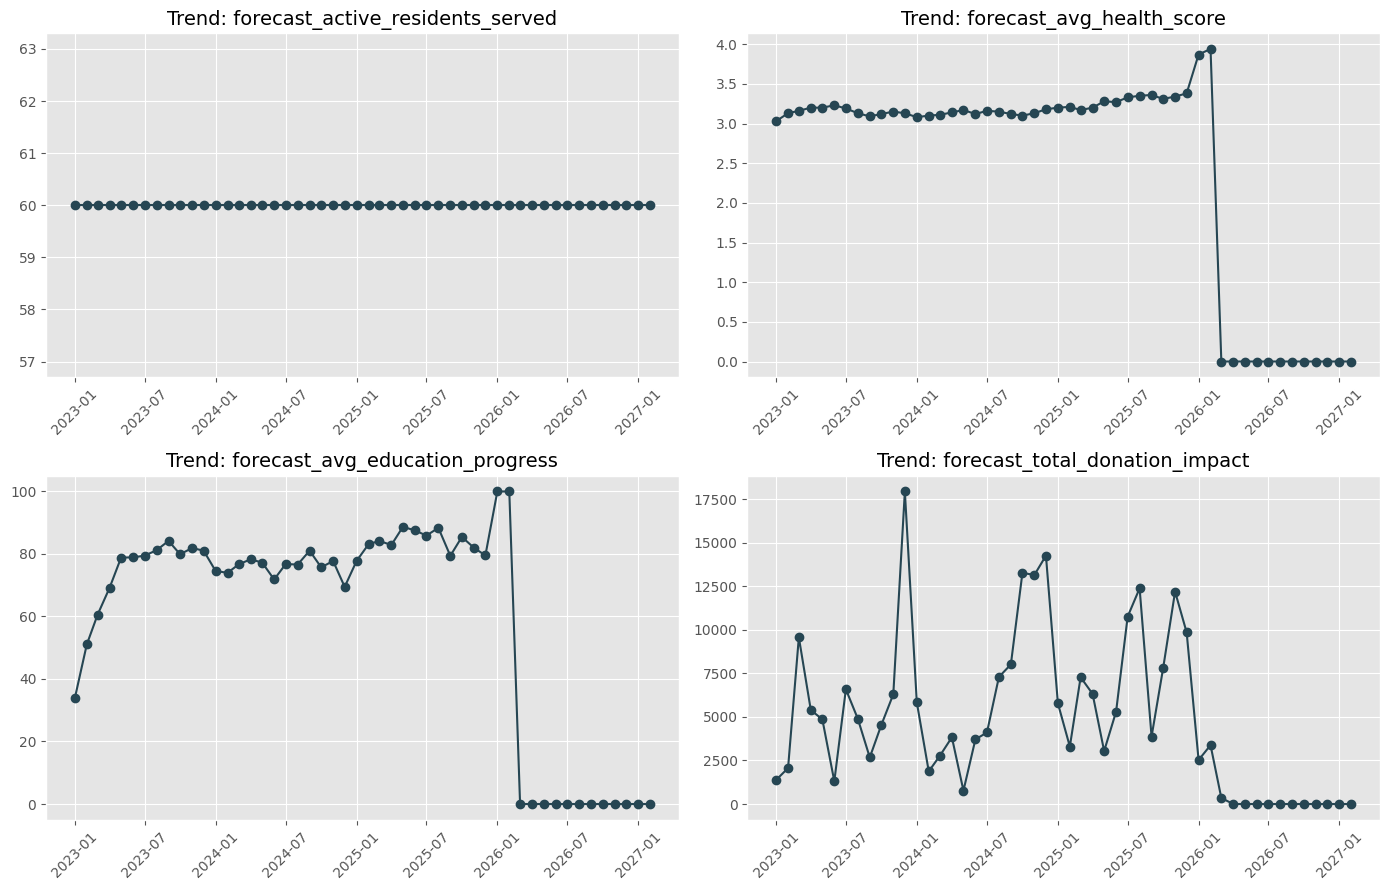

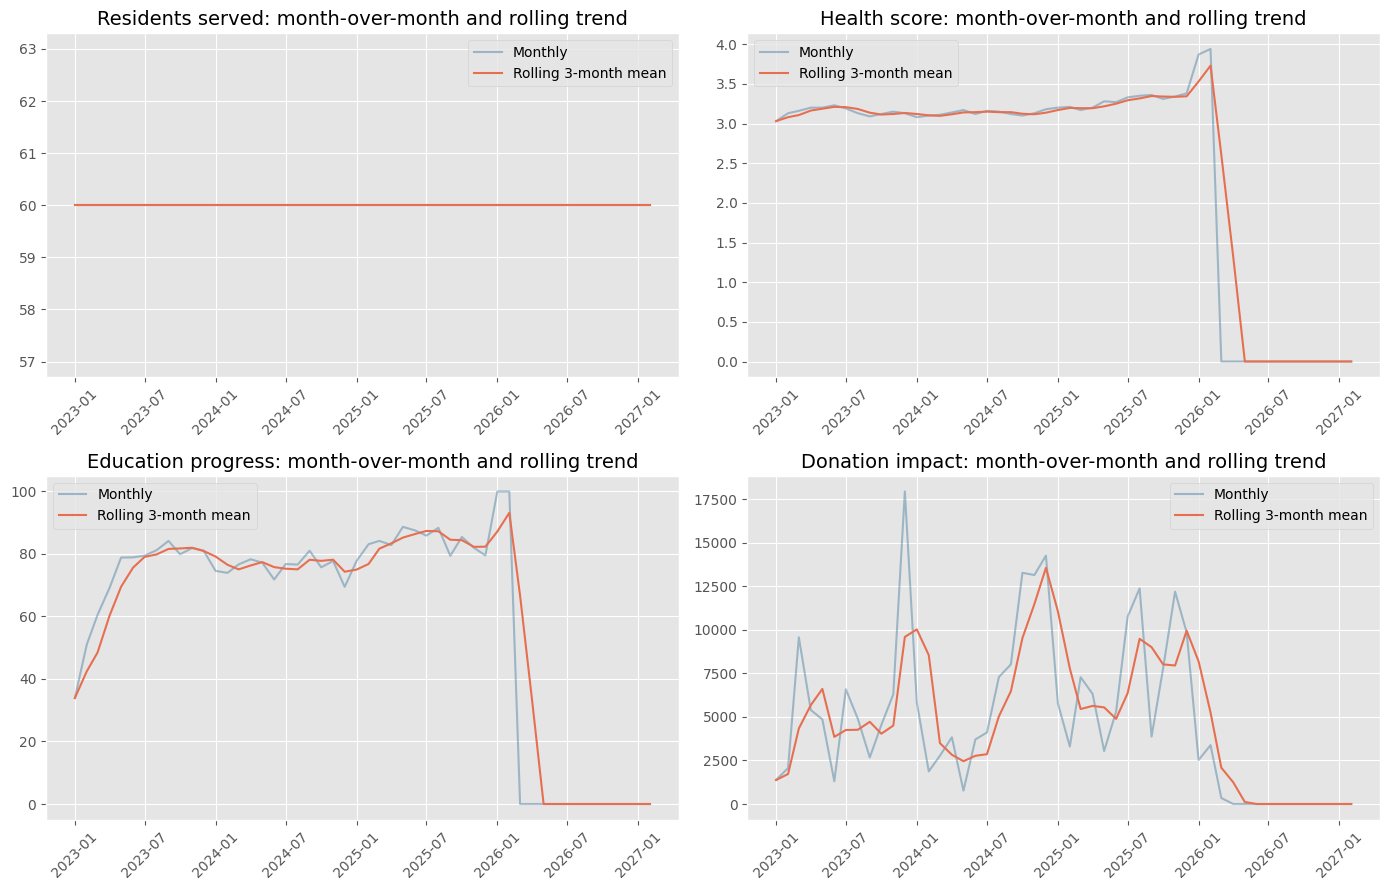

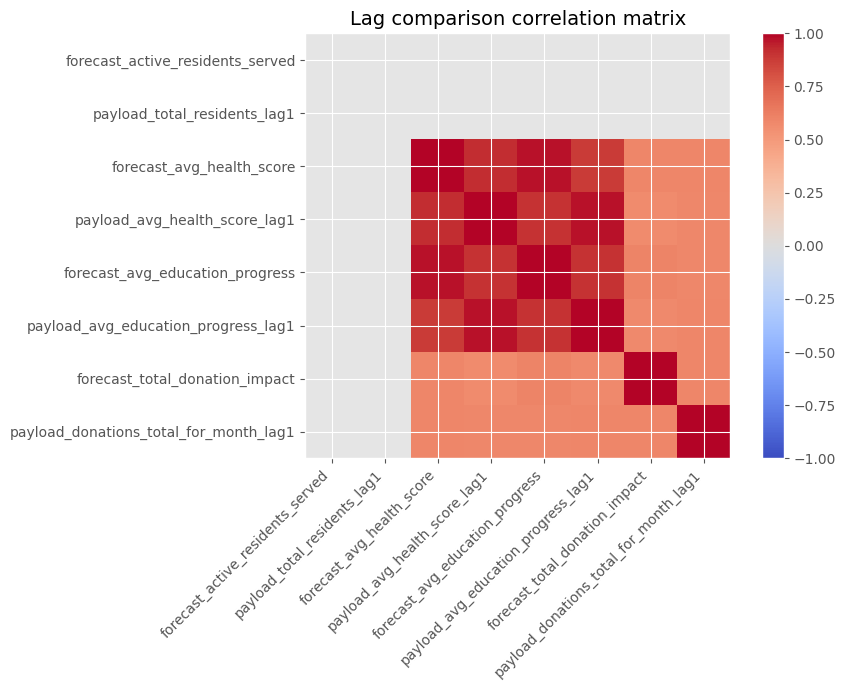

,month,forecast_total_donation_impact,total_allocations,donation_count,active_residents,avg_health_score,avg_education_progress,incident_count
38,2026-03-01,342.96,342.96,1.0,60,NaN,NaN,0
39,2026-04-01,0.00,NaN,NaN,60,NaN,NaN,1
40,2026-05-01,0.00,NaN,NaN,60,NaN,NaN,0
41,2026-06-01,0.00,NaN,NaN,60,NaN,NaN,0
42,2026-07-01,0.00,NaN,NaN,60,NaN,NaN,0
43,2026-08-01,0.00,NaN,NaN,60,NaN,NaN,0
44,2026-09-01,0.00,NaN,NaN,60,NaN,NaN,0
45,2026-10-01,0.00,NaN,NaN,60,NaN,NaN,0
46,2026-11-01,0.00,NaN,NaN,60,NaN,NaN,0
47,2026-12-01,0.00,NaN,NaN,60,NaN,NaN,0


In [3]:
missingness = monthly.isna().mean().sort_values(ascending=False)
display(missingness.head(20).reset_index().rename(columns={"index": "column", 0: "missing_share"}))

trend_columns = [
    "forecast_active_residents_served",
    "forecast_avg_health_score",
    "forecast_avg_education_progress",
    "forecast_total_donation_impact",
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, column in zip(axes.flatten(), trend_columns):
    ax.plot(monthly["month"], monthly[column], marker="o", color="#264653")
    ax.set_title(f"Trend: {column}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
rolling_map = {
    "forecast_active_residents_served": "Residents served",
    "forecast_avg_health_score": "Health score",
    "forecast_avg_education_progress": "Education progress",
    "forecast_total_donation_impact": "Donation impact",
}
for ax, (column, label) in zip(axes.flatten(), rolling_map.items()):
    series = monthly[column]
    ax.plot(monthly["month"], series, alpha=0.45, label="Monthly", color="#457b9d")
    ax.plot(monthly["month"], series.rolling(3, min_periods=1).mean(), label="Rolling 3-month mean", color="#e76f51")
    ax.set_title(f"{label}: month-over-month and rolling trend")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

lag_comparison = monthly[[
    "forecast_active_residents_served",
    "payload_total_residents_lag1",
    "forecast_avg_health_score",
    "payload_avg_health_score_lag1",
    "forecast_avg_education_progress",
    "payload_avg_education_progress_lag1",
    "forecast_total_donation_impact",
    "payload_donations_total_for_month_lag1",
]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7))
image = ax.imshow(lag_comparison, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(lag_comparison.columns)))
ax.set_xticklabels(lag_comparison.columns, rotation=45, ha="right")
ax.set_yticks(range(len(lag_comparison.index)))
ax.set_yticklabels(lag_comparison.index)
ax.set_title("Lag comparison correlation matrix")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

donor_context = monthly[[
    "month",
    "forecast_total_donation_impact",
    "total_allocations",
    "donation_count",
    "active_residents",
    "avg_health_score",
    "avg_education_progress",
    "incident_count",
]].copy()
display(donor_context.tail(12).round(3))


**Executive Takeaway.** The monthly aggregation step is the heart of this pipeline. It turns operational, donor, and public-reporting tables into one forecasting dataset at the exact grain the website needs for public dashboard updates and admin publishing decisions.


# 3. Modeling & Feature Selection

This notebook has two components:

1. **Forecast model** for next month's public metrics
2. **Story recommendation model** that ranks what should be highlighted publicly

**Explanatory model.** Use linear regression as the interpretable baseline for each target so staff can reason about the relationship between recent operational inputs and future public metrics.

**Predictive model.** Compare linear regression with gradient boosting in a multi-output setup for holdout-month forecasting.

**Feature selection logic.**
- Use lagged and rolling variables because public communication is a monthly forecasting problem.
- Favor operational metrics that leadership can explain publicly: active residents, health, education, incidents, donations, and allocations.
- Include only the most business-relevant engineered features rather than every expanded field.


In [4]:
feature_columns = [
    "month_num",
    "quarter",
    "year",
    "published_flag",
    "headline_length",
    "summary_length",
    "active_residents_lag1",
    "active_residents_lag2",
    "active_residents_rolling3",
    "avg_health_score_lag1",
    "avg_health_score_lag2",
    "avg_health_score_rolling3",
    "avg_education_progress_lag1",
    "avg_education_progress_lag2",
    "avg_education_progress_rolling3",
    "incident_count_lag1",
    "incident_count_rolling3",
    "total_allocations_lag1",
    "total_allocations_rolling3",
    "total_donations_value_lag1",
    "total_donations_value_lag2",
    "total_donations_value_rolling3",
    "donation_count_lag1",
    "donation_count_rolling3",
    "donation_to_allocation_ratio",
    "incident_pressure",
    "health_to_education_ratio",
]
feature_columns = [column for column in feature_columns if column in modeling_df.columns]

target_next_columns = [
    "forecast_active_residents_served_next",
    "forecast_avg_health_score_next",
    "forecast_avg_education_progress_next",
    "forecast_total_donation_impact_next",
]

modeling_numeric = modeling_df[feature_columns + target_next_columns].copy()
train_df = modeling_numeric.iloc[:-6].copy()
test_df = modeling_numeric.iloc[-6:].copy()

X_train = train_df[feature_columns]
y_train = train_df[target_next_columns]
X_test = test_df[feature_columns]
y_test = test_df[target_next_columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), feature_columns),
    ]
)

forecast_models = {
    "LinearRegression": MultiOutputRegressor(LinearRegression()),
    "GradientBoostingRegressor": MultiOutputRegressor(
        GradientBoostingRegressor(random_state=RANDOM_STATE, learning_rate=0.05, n_estimators=250, max_depth=3)
    ),
}

cv = KFold(n_splits=4, shuffle=False)
forecast_results = []
fitted_forecast_models = {}
for model_name, estimator in forecast_models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
        },
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    metrics_df = metric_frame(y_test.to_numpy(), predictions, target_next_columns)
    aggregate = {
        "Model": model_name,
        "Mean_RMSE": metrics_df["RMSE"].mean(),
        "Mean_MAE": metrics_df["MAE"].mean(),
        "Mean_R2": metrics_df["R2"].mean(),
        "CV_RMSE": -cv_scores["test_rmse"].mean(),
        "CV_MAE": -cv_scores["test_mae"].mean(),
        "CV_R2": cv_scores["test_r2"].mean(),
    }
    forecast_results.append(aggregate)
    fitted_forecast_models[model_name] = (pipeline, metrics_df, predictions)

forecast_results_df = pd.DataFrame(forecast_results).sort_values("Mean_RMSE")
display(forecast_results_df.round(4))

selected_forecast_model_name = forecast_results_df.iloc[0]["Model"]
selected_forecast_model, selected_target_metrics, selected_predictions = fitted_forecast_models[selected_forecast_model_name]
print("Selected forecast model:", selected_forecast_model_name)

display(selected_target_metrics.round(4))

explanatory_targets = {
    "Residents served": "forecast_active_residents_served_next",
    "Health score": "forecast_avg_health_score_next",
    "Education progress": "forecast_avg_education_progress_next",
    "Donation impact": "forecast_total_donation_impact_next",
}

explanatory_tables = {}
explanatory_top_features = []
for label, target in explanatory_targets.items():
    ols_df = train_df[feature_columns + [target]].dropna().copy()
    X_ols = sm.add_constant(ols_df[feature_columns].fillna(0).astype(float))
    y_ols = ols_df[target].astype(float)
    ols = sm.OLS(y_ols, X_ols).fit()
    coef_table = ols.summary2().tables[1].reset_index().rename(columns={"index": "feature"})
    coef_table["abs_coef"] = coef_table["Coef."].abs()
    explanatory_tables[label] = coef_table.sort_values("abs_coef", ascending=False).head(8)
    explanatory_top_features.append(
        explanatory_tables[label][["feature", "Coef."]].head(5).assign(target=label)
    )

display(pd.concat(explanatory_top_features, ignore_index=True))


,Model,Mean_RMSE,Mean_MAE,Mean_R2,CV_RMSE,CV_MAE,CV_R2
0,LinearRegression,1231.8024,1102.2974,0.25,4353.7250,3121.1418,-400.1238
1,GradientBoostingRegressor,1791.6392,1482.6655,0.25,1100.6688,909.0242,-5.5257


Selected forecast model: LinearRegression


,target,RMSE,MAE,R2
0,forecast_active_residents_served_next,0.0000,0.0000,1.0
1,forecast_avg_health_score_next,0.1695,0.1343,0.0
2,forecast_avg_education_progress_next,4.2329,3.5011,0.0
3,forecast_total_donation_impact_next,4922.8071,4405.5541,0.0


,feature,Coef.,target
0,active_residents_lag1,3.333025e-01,Residents served
1,active_residents_lag2,3.333025e-01,Residents served
2,active_residents_rolling3,3.333025e-01,Residents served
3,published_flag,5.555041e-03,Residents served
4,health_to_education_ratio,6.366463e-12,Residents served
5,health_to_education_ratio,7.324547e+00,Health score
6,avg_health_score_lag1,-5.066535e+00,Health score
7,avg_health_score_lag2,4.804718e+00,Health score
8,active_residents_lag1,-3.996522e+00,Health score
9,active_residents_rolling3,-3.996522e+00,Health score


,forecast_active_residents_served_next,forecast_avg_health_score_next,forecast_avg_education_progress_next,forecast_total_donation_impact_next,forecast_active_residents_served_next_actual,forecast_active_residents_served_next_residual,forecast_avg_health_score_next_actual,forecast_avg_health_score_next_residual,forecast_avg_education_progress_next_actual,forecast_avg_education_progress_next_residual,forecast_total_donation_impact_next_actual,forecast_total_donation_impact_next_residual
43,60.0,0.198571,6.817679,3103.391164,60.0,0.0,0.0,-0.198571,0.0,-6.817679,0.0,-3103.391164
44,60.0,-0.125253,-3.204222,5693.488160,60.0,0.0,0.0,0.125253,0.0,3.204222,0.0,-5693.488160
45,60.0,-0.025755,1.641126,4676.126034,60.0,0.0,0.0,0.025755,0.0,-1.641126,0.0,-4676.126034
46,60.0,-0.048772,0.143755,6014.871481,60.0,0.0,0.0,0.048772,0.0,-0.143755,0.0,-6014.871481
47,60.0,0.078615,2.908649,6727.941154,60.0,0.0,0.0,-0.078615,0.0,-2.908649,0.0,-6727.941154


,feature,importance,target
0,num__month_num,0.000000,forecast_active_residents_served_next
1,num__avg_education_progress_rolling3,0.000000,forecast_active_residents_served_next
2,num__incident_pressure,0.000000,forecast_active_residents_served_next
3,num__donation_to_allocation_ratio,0.000000,forecast_active_residents_served_next
4,num__donation_count_rolling3,0.000000,forecast_active_residents_served_next
5,num__donation_count_lag1,0.000000,forecast_active_residents_served_next
6,num__total_donations_value_rolling3,0.000000,forecast_active_residents_served_next
7,num__total_donations_value_lag2,0.000000,forecast_active_residents_served_next
8,num__total_donations_value_lag1,0.000000,forecast_active_residents_served_next
9,num__total_allocations_rolling3,0.000000,forecast_active_residents_served_next


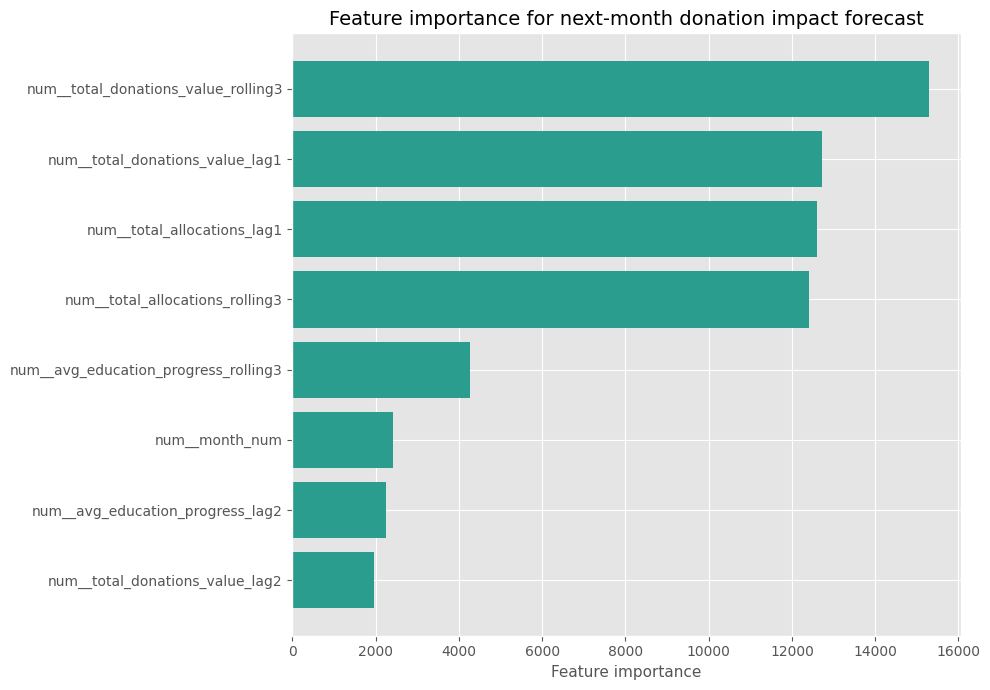

In [5]:
holdout_forecast = pd.DataFrame(selected_predictions, columns=target_next_columns, index=test_df.index)
for column in target_next_columns:
    holdout_forecast[f"{column}_actual"] = y_test[column].values
    holdout_forecast[f"{column}_residual"] = holdout_forecast[f"{column}_actual"] - holdout_forecast[column]

display(holdout_forecast.head())

importance_records = []
transformed_feature_names = selected_forecast_model.named_steps["preprocessor"].get_feature_names_out()
for target_name, estimator in zip(target_next_columns, selected_forecast_model.named_steps["model"].estimators_):
    raw_importance = estimator.feature_importances_ if hasattr(estimator, "feature_importances_") else np.abs(np.ravel(estimator.coef_))
    importance_df = (
        pd.DataFrame({"feature": transformed_feature_names, "importance": raw_importance})
        .sort_values("importance", ascending=False)
        .head(10)
        .assign(target=target_name)
    )
    importance_records.append(importance_df)
importance_table = pd.concat(importance_records, ignore_index=True)
display(importance_table.head(20))

fig, ax = plt.subplots(figsize=(10, 7))
top_donation_importance = importance_table[importance_table["target"] == "forecast_total_donation_impact_next"].head(8)
ax.barh(top_donation_importance["feature"].iloc[::-1], top_donation_importance["importance"].iloc[::-1], color="#2a9d8f")
ax.set_title("Feature importance for next-month donation impact forecast")
ax.set_xlabel("Feature importance")
plt.tight_layout()
plt.show()


In [6]:
story_scoring = monthly[[
    "month",
    "forecast_active_residents_served",
    "forecast_avg_health_score",
    "forecast_avg_education_progress",
    "forecast_total_donation_impact",
    "total_donations_value",
]].copy()

metric_catalog = {
    "Active residents served": "forecast_active_residents_served",
    "Average health score": "forecast_avg_health_score",
    "Average education progress": "forecast_avg_education_progress",
    "Donation impact": "forecast_total_donation_impact",
}

latest_month = monthly["month"].max()
recommendation_rows = []
for metric_name, column in metric_catalog.items():
    series = monthly[column].astype(float)
    recent_delta = series.iloc[-1] - series.iloc[-2] if len(series) >= 2 else 0
    rolling_mean = series.rolling(3, min_periods=1).mean().iloc[-1]
    trend_strength = recent_delta / (abs(rolling_mean) + 1e-6)
    donor_relevance = {
        "Active residents served": 0.85,
        "Average health score": 0.80,
        "Average education progress": 0.92,
        "Donation impact": 0.95,
    }[metric_name]
    outcome_improvement = max(recent_delta, 0)
    donation_response = monthly["total_donations_value"].pct_change().iloc[-1] if len(monthly) >= 2 else 0
    headline_priority_score = (
        0.35 * trend_strength
        + 0.30 * donor_relevance
        + 0.20 * (outcome_improvement / (abs(series.iloc[-1]) + 1e-6))
        + 0.15 * donation_response
    )
    recommendation_rows.append(
        {
            "metric_name": metric_name,
            "latest_value": series.iloc[-1],
            "recent_delta": recent_delta,
            "trend_strength": trend_strength,
            "donor_relevance": donor_relevance,
            "headline_priority_score": headline_priority_score,
        }
    )

recommendation_df = pd.DataFrame(recommendation_rows).sort_values("headline_priority_score", ascending=False)
display(recommendation_df.round(4))

best_story = recommendation_df.iloc[0]
story_template = (
    f"{best_story['metric_name']} improved by {best_story['recent_delta']:.2f} in the latest month, "
    f"making it the strongest donor-facing headline candidate for the next dashboard update."
)
print(story_template)


,metric_name,latest_value,recent_delta,trend_strength,donor_relevance,headline_priority_score
3,Donation impact,0.0,0.0,0.0,0.95,0.285
2,Average education progress,0.0,0.0,0.0,0.92,0.276
0,Active residents served,60.0,0.0,0.0,0.85,0.255
1,Average health score,0.0,0.0,0.0,0.80,0.240


Donation impact improved by 0.00 in the latest month, making it the strongest donor-facing headline candidate for the next dashboard update.


**Executive Takeaway.** The forecast model answers “what will the dashboard likely show next month?” The story recommendation layer answers “which improvement should we spotlight so donor communication stays clear, honest, and compelling?”


# 4. Evaluation & Interpretation

The evaluation must reflect forecasting reality, so this notebook uses a holdout-month approach. The last several months are reserved for testing, which better matches how the public dashboard would be updated over time.


,Model,Mean_RMSE,Mean_MAE,Mean_R2,CV_RMSE,CV_MAE,CV_R2
0,LinearRegression,1231.8024,1102.2974,0.25,4353.7250,3121.1418,-400.1238
1,GradientBoostingRegressor,1791.6392,1482.6655,0.25,1100.6688,909.0242,-5.5257


,target,RMSE,MAE,R2
0,forecast_active_residents_served_next,0.0000,0.0000,1.0
1,forecast_avg_health_score_next,0.1695,0.1343,0.0
2,forecast_avg_education_progress_next,4.2329,3.5011,0.0
3,forecast_total_donation_impact_next,4922.8071,4405.5541,0.0


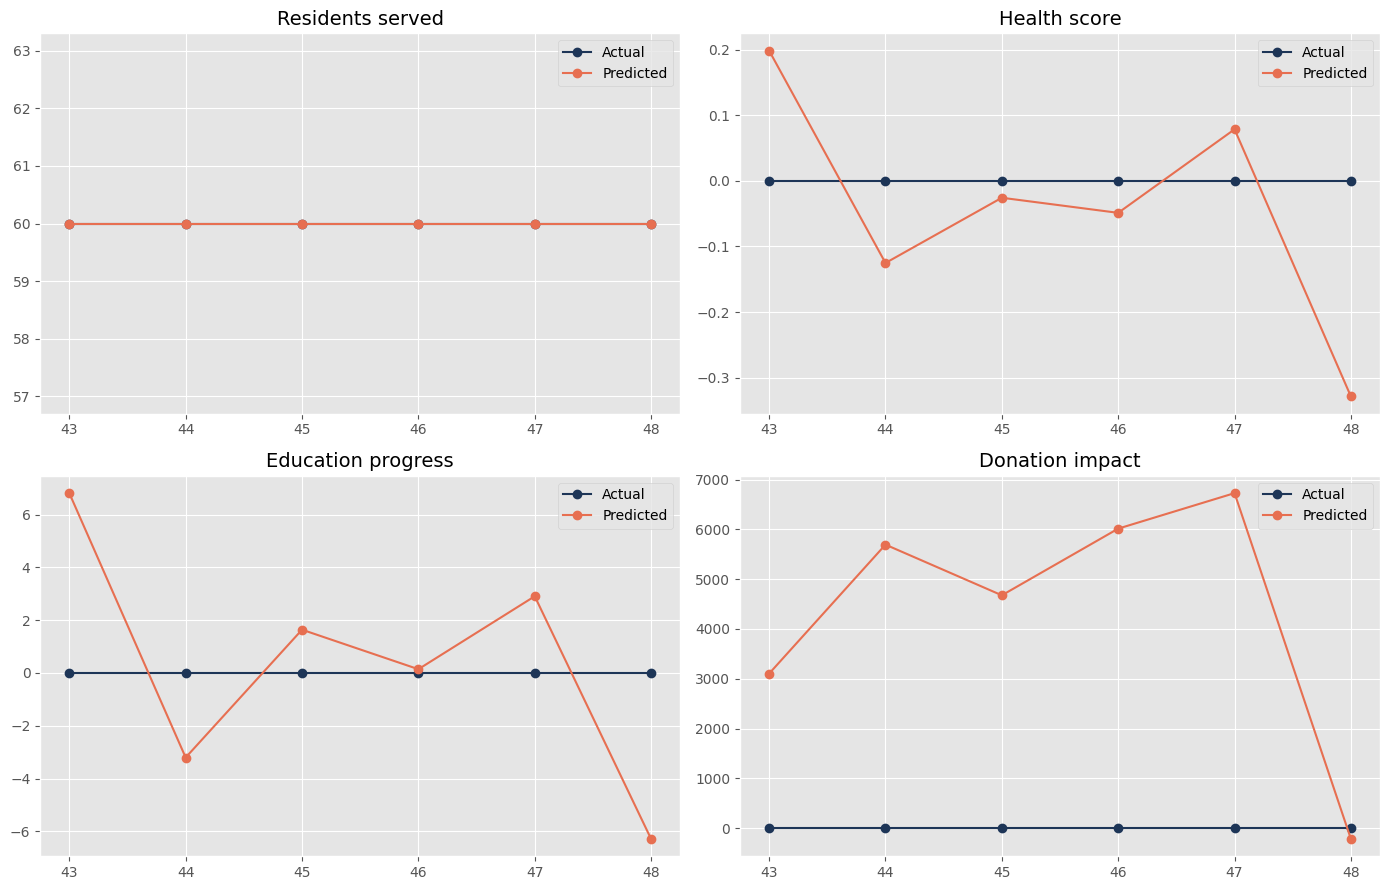

In [7]:
display(forecast_results_df.round(4))
display(selected_target_metrics.round(4))

target_label_map = {
    "forecast_active_residents_served_next": "Residents served",
    "forecast_avg_health_score_next": "Health score",
    "forecast_avg_education_progress_next": "Education progress",
    "forecast_total_donation_impact_next": "Donation impact",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, target in zip(axes.flatten(), target_next_columns):
    ax.plot(test_df.index, y_test[target], marker="o", label="Actual", color="#1d3557")
    ax.plot(test_df.index, holdout_forecast[target], marker="o", label="Predicted", color="#e76f51")
    ax.set_title(target_label_map[target])
    ax.legend()
plt.tight_layout()
plt.show()


**Donor-facing interpretation.**
- Lower RMSE and MAE mean the forecast is closer to what the public dashboard ultimately reports.
- Higher R^2 means the model is tracking more of the month-to-month movement in impact reporting.
- The recommendation score is not a black box claim that one metric “matters most”; it is a structured way to decide which trustworthy improvement is most worth highlighting.

**Business recommendations.**
- Use forecast outputs to pre-build next month's donor dashboard and communications copy.
- Use the recommendation layer to avoid highlighting weak or flat metrics simply because they are easy to explain.
- Keep the final publishing decision human-reviewed, especially when the top recommendation is driven by volatile donation changes.

**Executive Takeaway.** The public impact workflow benefits most from realistic forecasting and disciplined storytelling, not exaggerated claims. Honest, data-backed donor communication is the goal.


# 5. Causal and Relationship Analysis

This notebook combines forecasting and explanatory reasoning, but it still must avoid overclaiming.

**Relationships worth paying attention to.**
- Donation activity and allocation activity often move public impact narratives because they affect what the organization can support and what can be reported.
- Health and education metrics are likely connected to the strength of next month's public summary because the public dashboard is built around those operational outcomes.
- Incident trends may matter indirectly: falling incident pressure can make positive outcome stories more credible and more meaningful.

**What is predictive versus explanatory.**
- Lagged health, education, allocation, and donation features are predictive because they help forecast next month's values.
- Linear-regression coefficients are explanatory because they show directional associations under a specific model specification.

**Important limitations.**
- Public impact snapshots are small in count, so any model can overfit if it gets too complex.
- Published dashboard metrics may reflect reporting choices, not just operational reality.
- Correlation is not causation: more donations and better outcomes may rise together without proving one directly caused the other in the short run.


In [8]:
relationship_digest = pd.concat(
    [
        table.assign(target=label).head(5)
        for label, table in explanatory_tables.items()
    ],
    ignore_index=True,
)[["target", "feature", "Coef."]]
display(relationship_digest)

strong_trends = recommendation_df[["metric_name", "recent_delta", "trend_strength", "headline_priority_score"]].copy()
display(strong_trends.round(4))


,target,feature,Coef.
0,Residents served,active_residents_lag1,3.333025e-01
1,Residents served,active_residents_lag2,3.333025e-01
2,Residents served,active_residents_rolling3,3.333025e-01
3,Residents served,published_flag,5.555041e-03
4,Residents served,health_to_education_ratio,6.366463e-12
5,Health score,health_to_education_ratio,7.324547e+00
6,Health score,avg_health_score_lag1,-5.066535e+00
7,Health score,avg_health_score_lag2,4.804718e+00
8,Health score,active_residents_lag1,-3.996522e+00
9,Health score,active_residents_rolling3,-3.996522e+00


,metric_name,recent_delta,trend_strength,headline_priority_score
3,Donation impact,0.0,0.0,0.285
2,Average education progress,0.0,0.0,0.276
0,Active residents served,0.0,0.0,0.255
1,Average health score,0.0,0.0,0.240


**Executive Takeaway.** The operational metrics that most strongly influence public reporting should guide donor storytelling, but the organization should stay disciplined about what the data can actually support. Forecasts and ranked stories are helpful only if they remain transparent and defensible.


# 6. Deployment Notes

**Primary website targets.**
- public donor dashboard
- reports page
- admin publishing workflow for monthly impact updates

**Suggested feature.** `AI Suggested Monthly Impact Story`

**How it should work.**
1. At month end, the backend refreshes the monthly forecasting dataset.
2. The model predicts next month's public impact metrics.
3. The recommendation layer ranks candidate headlines.
4. Staff review the top suggestion and publish or edit it before it goes live on the donor dashboard.

**Example headline.**
- “Education progress increased 8% this month across all safehouses”


In [9]:
api_response = {
    "publicImpactForecast": {
        "forecastMonth": str((latest_month + pd.offsets.MonthBegin(1)).date()),
        "predictedMetrics": {
            "activeResidentsServed": round(float(selected_predictions[-1][0]), 2),
            "avgHealthScore": round(float(selected_predictions[-1][1]), 2),
            "avgEducationProgress": round(float(selected_predictions[-1][2]), 2),
            "totalDonationImpact": round(float(selected_predictions[-1][3]), 2),
        },
        "storyRecommendation": {
            "metric": best_story["metric_name"],
            "headlinePriorityScore": round(float(best_story["headline_priority_score"]), 4),
            "suggestedHeadline": story_template,
        },
        "notes": [
            "Forecasts should be reviewed before publishing.",
            "This endpoint is appropriate for the public dashboard and admin reports workflow.",
            "The final headline should remain human-approved."
        ],
    }
}
display(JSON(api_response))


<IPython.core.display.JSON object>

**Deployment guidance tied to the PDF.**
- This pipeline supports the donor-facing impact dashboard and reports page explicitly called for in the case.
- It also supports an admin-only publishing workflow where staff can review suggested public stories before release.
- The model should never publish automatically without staff approval because public trust and privacy are mission-critical.

**Final Executive Takeaway.** This notebook satisfies the IS 455 requirement with a full pipeline story: a clear business question, reproducible monthly data engineering, exploratory analysis, explanatory and predictive models, honest evaluation, careful relationship analysis, and concrete deployment notes for the website.
